In [20]:
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [21]:

# Load only specific columns
particles = load_dataset(
    "CERN/ColliderML-Release-1",
    "ttbar_pu0_calo_hits",
    split="train",
    
    streaming=True, 
)




Resolving data files:   0%|          | 0/1000 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1000 [00:00<?, ?it/s]

In [22]:
NUM_EVENTS = 3

keys = ["total_energy", "x", "y", "z", "detector"]

data_dir = {key:[] for key in keys}
energies, x, y, z, detector = {}, {}, {}, {}, {}


for i, event in enumerate(tqdm(particles, total=NUM_EVENTS)):
    if i >= NUM_EVENTS:
        break

    for key in data_dir.keys():
        data_dir[key].append(event[key])

   
for key in data_dir.keys():
    data_dir[key] = np.concatenate(data_dir[key])


100%|██████████| 3/3 [00:18<00:00,  6.33s/it]


In [23]:
data_dir["r"] = np.sqrt(data_dir["x"]**2 + data_dir["y"]**2)

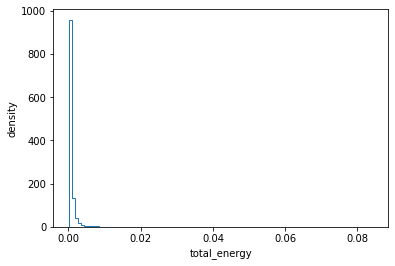

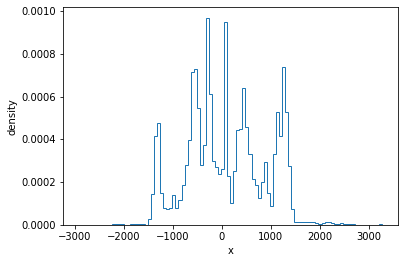

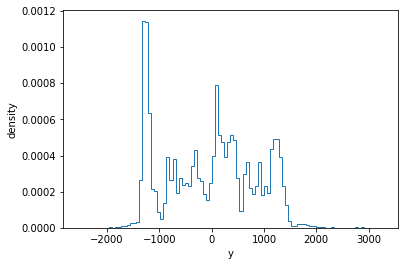

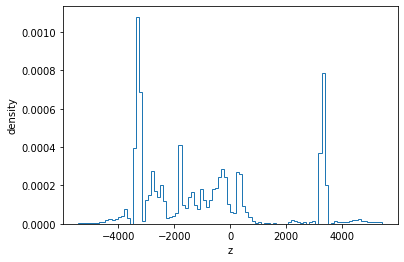

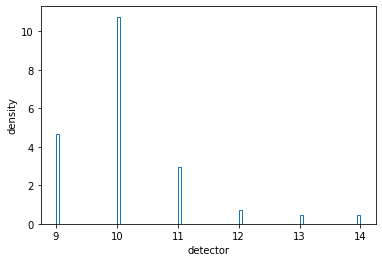

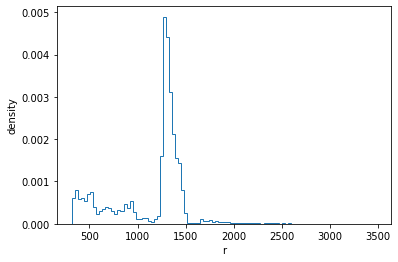

In [24]:
for key in data_dir.keys():
    plt.figure()
    plt.hist(data_dir[key], bins = 100, histtype = "step", density = True)
    plt.xlabel(key)
    plt.ylabel("density")
    plt.show()

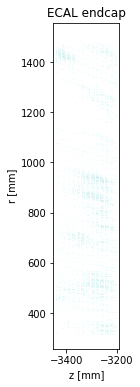

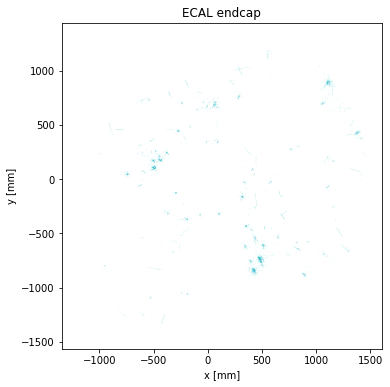

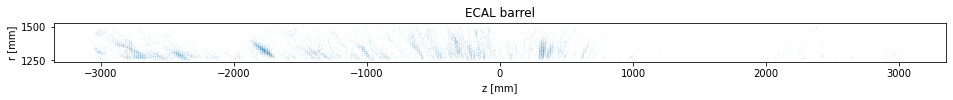

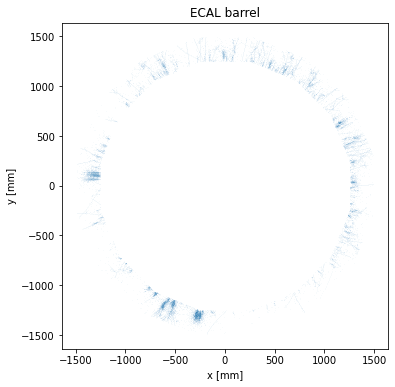

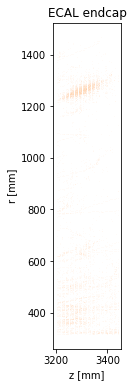

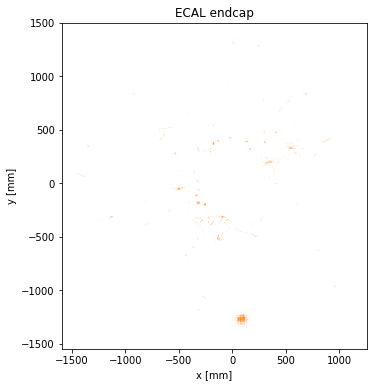

In [25]:
ECAL_layers = [9, 10, 11]
labels = ["ECAL endcap", "ECAL barrel", "ECAL endcap"]


for i, detector_idx in enumerate(ECAL_layers):
    detector_mask = data_dir["detector"] == detector_idx

    plt.figure(figsize = (16, 6))
    plt.scatter(
        data_dir["z"][detector_mask], 
        data_dir["r"][detector_mask], 
        color = f"C{detector_idx}", 
        s = 0.0001,
        label = labels[i]
        )
   # plt.legend(loc = (1, 0))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(labels[i])
    plt.xlabel("z [mm]")
    plt.ylabel("r [mm]")
    plt.show()


    plt.figure(figsize = (16, 6))
    
    plt.scatter(
        data_dir["x"][detector_mask], 
        data_dir["y"][detector_mask], 
        color = f"C{detector_idx}", 
        s = 0.000100,
        label = labels[i]
        )
   #plt.legend(loc = (1, 0))
    plt.title(labels[i])
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlabel("x [mm]")
    plt.ylabel("y [mm]")
    plt.show()




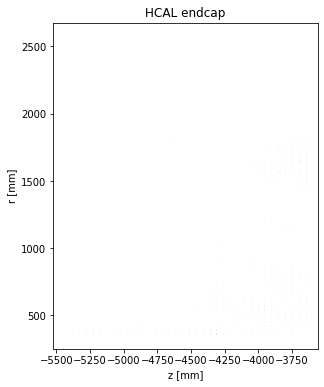

KeyboardInterrupt: 

In [ ]:
HCAL_layers = [12, 13, 14]
labels = ["HCAL endcap", "HCAL barrel", "HCAL endcap"]


for i, detector_idx in enumerate(HCAL_layers):
    detector_mask = data_dir["detector"] == detector_idx

    plt.figure(figsize = (16, 6))
    plt.scatter(
        data_dir["z"][detector_mask], 
        data_dir["r"][detector_mask], 
        color = f"C{detector_idx}", 
        s = 0.0001,
        label = labels[i]
        )
   # plt.legend(loc = (1, 0))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(labels[i])
    plt.xlabel("z [mm]")
    plt.ylabel("r [mm]")
    plt.show()


    plt.figure(figsize = (16, 6))
    
    plt.scatter(
        data_dir["x"][detector_mask], 
        data_dir["y"][detector_mask], 
        color = f"C{detector_idx}", 
        s = 0.000100,
        label = labels[i]
        )
   #plt.legend(loc = (1, 0))
    plt.title(labels[i])
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlabel("x [mm]")
    plt.ylabel("y [mm]")
    plt.show()




In [ ]:
import numpy as np


def assign_hits_to_cells(x, y, z, detector_index, n_sectors=16, half_wedge=np.pi/16):
    """
    Assign hits to HCAL cells in endcap.
    Sector 0 is fixed; all other sectors rotated to align with sector 0.
    """

    #TODO: Z = ABS Z
    # TODO failsafe if dcant be indexed

    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)

    

    # HCAL
    if detector_index in [12, 13, 14]:
        cell_size = 30.0 # mm
        layer_width = 51.0 # mm
        y_start, y_stop = -660.0, 660.0 + cell_size # 45 bins
    # ECAL
    elif detector_index in [9, 10, 11]:
        cell_size = 5.1 # mm
        layer_width = 5.05 # mm
        y_start, y_stop = -295.8, 295.8 # 117 bins

    # HCAL endcaps
    if detector_index in [12, 14]:
        x_start, x_stop = 362.5, 3362.5 # 100 bins
        z_start, z_stop = 3647.5, 5483.5 # 36 bins / layers 
        if detector_index == 12:
            z_start, z_stop = -z_stop, -z_start
    
    # HCAL barrel
    elif detector_index in [13]:
        x_start, x_stop = 1647.5, 3483.5 # 36 bins / layers
        z_start, z_stop = -3450.0, 3450.0 + cell_size # 230 bins
        
    # ECAL endcaps
    elif detector_index in [9, 11]:
        x_start, x_stop = 316.8, 1469.4 # 227 bins
        z_start, z_stop = 3202.4, 3439.75 # 48 bins / layers
        if detector_index == 9:
            z_start, z_stop = -z_stop, -z_start
    
    # ECAL barrel
    elif detector_index in [10]:
        x_start, x_stop = 1252.4, 1494.8 # 48 bins / layers
        z_start, z_stop = -3049.8, 3049.8  # 1197 bins


    if detector_index in [9, 11, 12, 14]:
        # layers in z
        x_edges = np.arange(np.round(x_start - cell_size/2, 1), np.round(x_stop + cell_size/2, 1), cell_size)
        y_edges = np.arange(np.round(y_start - cell_size/2, 1), np.round(y_stop + cell_size/2, 1), cell_size)
        z_edges = np.arange(np.round(z_start - layer_width/2, 1), np.round(z_stop + layer_width/2, 1), layer_width)

    

    elif detector_index in [10, 13]:
        # layers in x
        x_edges = np.arange(np.round(x_start - layer_width/2, 1), np.round(x_stop + layer_width/2, 1), layer_width)
        y_edges = np.arange(np.round(y_start - cell_size/2, 1), np.round(y_stop + cell_size/2, 1), cell_size)
        z_edges = np.arange(np.round(z_start - cell_size/2, 1), np.round(z_stop + cell_size/2, 1), cell_size)

    print(x_edges)
    print(len(x_edges)-1)
    print()
    print(y_edges)
    print(len(y_edges)-1)
    print()
    print(z_edges)
    print(len(z_edges)-1)
    print()

    """
    print(len(x_edges)-1)
    print(len(y_edges)-1)
    print(len(z_edges)-1)
    """

    # --- Step 1: compute wedge ---
    angles = np.arctan2(y, x)
    angles[angles < 0] += 2*np.pi
    angles = (angles + half_wedge) % (2*np.pi)
    sector_idx = (angles / (2*np.pi) * n_sectors).astype(int)

    # --- Step 2: compute rotation angles to align with sector 0 ---
    delta_theta = 2*np.pi / n_sectors
    theta_center = (sector_idx + 0.5) * delta_theta
    theta_center_0 = (0 + 0.5) * delta_theta  # sector 0 center angle

    theta_rot = - (theta_center - theta_center_0)  # rotate other sectors to align with sector 0

    # --- Step 3: rotate hits into sector 0-aligned frame ---
    x_local = x * np.cos(theta_rot) - y * np.sin(theta_rot)
    y_local = x * np.sin(theta_rot) + y * np.cos(theta_rot)


    """
    print("x")
    tmp = np.unique(np.round(x_local, 2))
    print(tmp)
    print(tmp[1:] - tmp[:-1])
    print(np.min(tmp), np.max(tmp))

    print("y")
    tmp = np.unique(np.round(y_local, 2))
    print(tmp)
    print(tmp[1:] - tmp[:-1])
    print(np.min(tmp), np.max(tmp))

    print("z")
    tmp = np.unique(np.round(z, 2))
    print(tmp)
    print(tmp[1:] - tmp[:-1])
    print(np.min(tmp), np.max(tmp))
    """

    
    # --- Step 5: assign hits to cell indices ---
    x_cell_idx = np.digitize(x_local, x_edges) - 1  # subtract 1 to make 0-based
    y_cell_idx = np.digitize(y_local, y_edges) - 1
    z_cell_idx = np.digitize(z, z_edges) - 1

    # Mask for unassigned hits in any dimension
    unassigned_mask = (x_cell_idx == -1) | (y_cell_idx == -1) | (z_cell_idx == -1)

    # Extract coordinates of unassigned hits
    x_unassigned = x[unassigned_mask]
    y_unassigned = y[unassigned_mask]
    z_unassigned = z[unassigned_mask]

    # Print results
    #print(f"Number of unassigned hits: {len(x_unassigned)}")
    if len(x_unassigned) > 0:
        print(f"ERROR: {len(x_unassigned)} hits!!!")
        for xi, yi, zi in zip(x_unassigned, y_unassigned, z_unassigned):
            print(f"x={xi}, y={yi}, z={zi}")

    # print the x cell indices that had no hits
    print("x cell indices with no hits:", np.where(np.bincount(x_cell_idx) == 0)[0])
    print("y cell indices with no hits:", np.where(np.bincount(y_cell_idx) == 0)[0])
    print("z cell indices with no hits:", np.where(np.bincount(z_cell_idx) == 0)[0])

    # get the actual cell edge values for the bins with zero hits
    x_edges_no_hits = x_edges[np.where(np.bincount(x_cell_idx) == 0)[0]]
    y_edges_no_hits = y_edges[np.where(np.bincount(y_cell_idx) == 0)[0]]
    z_edges_no_hits = z_edges[np.where(np.bincount(z_cell_idx) == 0)[0]]
    print("x cell edges with no hits:", x_edges_no_hits)
    print("y cell edges with no hits:", y_edges_no_hits)
    print("z cell edges with no hits:", z_edges_no_hits)
    
    return sector_idx, x_cell_idx, y_cell_idx, z_cell_idx, x_local, y_local

dd = 14

# Example: assign cells for detector hits
x = data_dir["x"][data_dir["detector"] == dd]
y = data_dir["y"][data_dir["detector"] == dd]
z = data_dir["z"][data_dir["detector"] == dd]

sectors, x_cell_idx, y_cell_idx, z_cell_idx,  x_local, y_local  = assign_hits_to_cells(x,y,z, dd)

[ 347.5  377.5  407.5  437.5  467.5  497.5  527.5  557.5  587.5  617.5
  647.5  677.5  707.5  737.5  767.5  797.5  827.5  857.5  887.5  917.5
  947.5  977.5 1007.5 1037.5 1067.5 1097.5 1127.5 1157.5 1187.5 1217.5
 1247.5 1277.5 1307.5 1337.5 1367.5 1397.5 1427.5 1457.5 1487.5 1517.5
 1547.5 1577.5 1607.5 1637.5 1667.5 1697.5 1727.5 1757.5 1787.5 1817.5
 1847.5 1877.5 1907.5 1937.5 1967.5 1997.5 2027.5 2057.5 2087.5 2117.5
 2147.5 2177.5 2207.5 2237.5 2267.5 2297.5 2327.5 2357.5 2387.5 2417.5
 2447.5 2477.5 2507.5 2537.5 2567.5 2597.5 2627.5 2657.5 2687.5 2717.5
 2747.5 2777.5 2807.5 2837.5 2867.5 2897.5 2927.5 2957.5 2987.5 3017.5
 3047.5 3077.5 3107.5 3137.5 3167.5 3197.5 3227.5 3257.5 3287.5 3317.5
 3347.5]

[-675. -645. -615. -585. -555. -525. -495. -465. -435. -405. -375. -345.
 -315. -285. -255. -225. -195. -165. -135. -105.  -75.  -45.  -15.   15.
   45.   75.  105.  135.  165.  195.  225.  255.  285.  315.  345.  375.
  405.  435.  465.  495.  525.  555.  585.  615.  645.  675.]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- select hits for a given sector ---
sector_of_interest = 11
mask = sectors == sector_of_interest  # or whichever array you use

# --- create a unique cell ID per (x_cell_idx, y_cell_idx) ---
cell_ids = x_cell_idx[mask] + y_cell_idx[mask] * (x_cell_idx[mask].max() + 1)

# --- assign colors using a colormap ---
n_colors = max(20, len(np.unique(cell_ids)))  # ensure enough colors
colors = plt.cm.tab20(np.mod(cell_ids, 20))   # checkerboard / repeated colors if >20

# --- Plot in raw coordinates ---
plt.figure(figsize=(10, 10))
plt.scatter(
    x[mask], y[mask],
    c=colors,
    s=1,
    alpha=1
)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title(f"Hits in Sector {sector_of_interest}, colored by cell")
plt.show()

# --- Plot in sector 0-aligned coordinates ---
plt.figure(figsize=(20, 20))
plt.scatter(
    x_local[mask], y_local[mask],
    c=colors,
    s=10,
    alpha=1
)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title(f"Hits in Sector {sector_of_interest}, sector 0-aligned, colored by cell")
plt.show()

In [ ]:


unique_x_hits = set(x_cell_idx)
for i in range(48):
    in_x_layer = x_cell_idx==i
    print(i, np.min(y_cell_idx[in_x_layer]), np.max(y_cell_idx[in_x_layer]), len(set(y_cell_idx[in_x_layer])))


In [2]:


ECAL_cells_per_layer = {
   0:99,
   1:99,
   2:99,
   3:99,
   4:99,
   5:101,
   6:101,
   7:101,
   8:101,
   9:101,
   10:103,
   11:103,
   12:103,
   13:103,
   14:103,
   15:105,
   16:105,
   17:105,
   18:105,
   19:105,
   20:107,
   21:107,
   22:107,
   23:107,
   24:107,
   25:109,
   26:109,
   27:109,
   28:109,
   29:109,
   30:111,
   31:111,
   32:111,
   33:111,
   34:111,
   35:112,
   36:113,
   37:113,
   38:113,
   39:113,
   40:113,
   41:115,
   42:115,
   43:115,
   44:115,
   45:115,
   46:117,
   47:117
}


HCAL_cells_per_layer = {
   0:23,
   1:23,
   2:23,
   3:25,
   4:25,
   5:25,
   6:27,
   7:27,
   8:27,
   9:29,
   10:29,
   11:29,
   12:31,
   13:31,
   14:31,
   15:33,
   16:33,
   17:33,
   18:35,
   19:35,
   20:35,
   21:37,
   22:37,
   23:37,
   24:39,
   25:39,
   26:39,
   27:41,
   28:41,
   29:41,
   30:43,
   31:43,
   32:43,
   33:45,
   34:45,
   35:45,
}

HCAL_offsets = {}
for i in range(len(HCAL_cells_per_layer)):
    HCAL_offsets[i] = int((HCAL_cells_per_layer[i] - HCAL_cells_per_layer[0]) / 2)


ECAL_offsets = {}
for i in range(len(ECAL_cells_per_layer)):
    ECAL_offsets[i] = int((ECAL_cells_per_layer[i] - ECAL_cells_per_layer[0]) / 2)










In [7]:
detector_type = "HCAL"

if detector_type == "HCAL":
    cells_per_layer = HCAL_cells_per_layer
    offsets = HCAL_offsets
    cells_per_patch_phi = 4
    cells_per_patch_z = 5
    R = 100
    num_cells_z = 230
    r_start, r_stop = 1647.5, 3483.5 # 36 bins / layers
    z_start, z_stop = -3450.0, 3450.0 # 230 bins
    cell_size = 30.0 # mm
    layer_width = 51.0 # mm

elif detector_type == "ECAL":
    cells_per_layer = ECAL_cells_per_layer
    offsets = ECAL_offsets
    cells_per_patch_phi = 8
    cells_per_patch_z = 21
    R = 300
    num_cells_z = 1197

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

num_wedges = 16


plt.figure(figsize=(30, 30))

patches_per_layer = {}
delta_phi_per_layer = {}
delta_etas_per_layer = {}


wedge_extra_cells = offsets

for wedge in range(num_wedges):
    theta = np.pi/2 - 2 * np.pi * wedge / num_wedges  # keep your top wedge as reference

    cos_t = np.cos(theta)
    sin_t = np.sin(theta)


    for i in range(len(cells_per_layer.keys())):
        
        loc_cells_per_layer = cells_per_layer[i]

        if wedge == 0:
            num_patches = loc_cells_per_layer * 16 / cells_per_patch_phi
            if int(num_patches) != num_patches:
                print(f"WARNING: Layer {i} has non-integer number of patches: {num_patches}")
            patches_per_layer[i] = num_patches
            delta_phi_per_layer[i] = 2 * np.pi / num_wedges * cells_per_patch_phi / loc_cells_per_layer

      
            # get the center z point of each patch
           
            r_edges = np.arange(np.round(r_start - layer_width/2, 1), np.round(r_stop + layer_width/2, 1), layer_width)
            r_centers = (r_edges[:-1] + r_edges[1:]) / 2

            z_edges = np.arange(np.round(z_start - cell_size/2, 1), np.round(z_stop + cell_size/2, 1), cell_size)
            z_patch_centers = [np.mean(z_edges[i:i+cells_per_patch_z]) for i in range(0, len(z_edges)-cells_per_patch_z+1, cells_per_patch_z)]
            
            print(z_patch_centers)

            etas = np.arcsinh(z_patch_centers/r_centers[i])
            print(etas)
            delta_etas = etas[1:] - etas[:-1]
            print(delta_etas)
        
        

        start_position = -int((loc_cells_per_layer - cells_per_layer[0]) / 2)
        x_positions = np.arange(loc_cells_per_layer) + start_position
        y_positions = np.full_like(x_positions, i)

        # ✅ KEY: shift wedge outward (barrel)
        y_positions = y_positions + R

        # rotate around origin
        x_rot = x_positions * cos_t - y_positions * sin_t
        y_rot = x_positions * sin_t + y_positions * cos_t

        plt.scatter(x_rot, y_rot, s=5, color = f"C{i}")

        # boundaries
        current_position = start_position - 0.5 + wedge_extra_cells[i]
        while current_position <= loc_cells_per_layer + start_position:

            x0, y0 = current_position, i - 0.5 + R
            x1, y1 = current_position, i + 0.5 + R

            x0r = x0 * cos_t - y0 * sin_t
            y0r = x0 * sin_t + y0 * cos_t
            x1r = x1 * cos_t - y1 * sin_t
            y1r = x1 * sin_t + y1 * cos_t

            plt.plot([x0r, x1r], [y0r, y1r], color='black', linewidth=0.5)

            current_position += cells_per_patch_phi
        # calculate the number of cells not included in the last patch
        num_extra_cells = (loc_cells_per_layer - (current_position - start_position + 0.5)) % cells_per_patch_phi
        wedge_extra_cells[i] = cells_per_patch_phi - num_extra_cells
        #print(i,  wedge_extra_cells[i])
        

plt.gca().set_aspect('equal')
plt.title(f"{detector_type} Barrel - 16 wedges (true barrel geometry)")
plt.show()

[-3465. -3435. -3405. -3375. -3345. -3315. -3285. -3255. -3225. -3195.
 -3165. -3135. -3105. -3075. -3045. -3015. -2985. -2955. -2925. -2895.
 -2865. -2835. -2805. -2775. -2745. -2715. -2685. -2655. -2625. -2595.
 -2565. -2535. -2505. -2475. -2445. -2415. -2385. -2355. -2325. -2295.
 -2265. -2235. -2205. -2175. -2145. -2115. -2085. -2055. -2025. -1995.
 -1965. -1935. -1905. -1875. -1845. -1815. -1785. -1755. -1725. -1695.
 -1665. -1635. -1605. -1575. -1545. -1515. -1485. -1455. -1425. -1395.
 -1365. -1335. -1305. -1275. -1245. -1215. -1185. -1155. -1125. -1095.
 -1065. -1035. -1005.  -975.  -945.  -915.  -885.  -855.  -825.  -795.
  -765.  -735.  -705.  -675.  -645.  -615.  -585.  -555.  -525.  -495.
  -465.  -435.  -405.  -375.  -345.  -315.  -285.  -255.  -225.  -195.
  -165.  -135.  -105.   -75.   -45.   -15.    15.    45.    75.   105.
   135.   165.   195.   225.   255.   285.   315.   345.   375.   405.
   435.   465.   495.   525.   555.   585.   615.   645.   675.   705.
   735

NameError: name 'z' is not defined

<Figure size 2160x2160 with 0 Axes>

In [ ]:


total_patches = 0

print(f"Cells per patch in phi: {cells_per_patch_phi}, cells per patch in z: {cells_per_patch_z}")

for i in range(0, 36, 3):
    print(f"Layers {i}-{i+2}: {cells_per_layer[i]} cells / wedge, {patches_per_layer[i]} 2D boxes in r-phi, {patches_per_layer[i]*num_cells_z/cells_per_patch_z} patches in r-phi-z")
    total_patches += patches_per_layer[i]*num_cells_z/cells_per_patch_z
print(f"Total patches in r-phi-z: {total_patches}")

Cells per patch in phi: 4, cells per patch in z: 5
Layers 0-2: 23 cells / wedge, 92.0 2D boxes in r-phi, 4232.0 patches in r-phi-z
Layers 3-5: 25 cells / wedge, 100.0 2D boxes in r-phi, 4600.0 patches in r-phi-z
Layers 6-8: 27 cells / wedge, 108.0 2D boxes in r-phi, 4968.0 patches in r-phi-z
Layers 9-11: 29 cells / wedge, 116.0 2D boxes in r-phi, 5336.0 patches in r-phi-z
Layers 12-14: 31 cells / wedge, 124.0 2D boxes in r-phi, 5704.0 patches in r-phi-z
Layers 15-17: 33 cells / wedge, 132.0 2D boxes in r-phi, 6072.0 patches in r-phi-z
Layers 18-20: 35 cells / wedge, 140.0 2D boxes in r-phi, 6440.0 patches in r-phi-z
Layers 21-23: 37 cells / wedge, 148.0 2D boxes in r-phi, 6808.0 patches in r-phi-z
Layers 24-26: 39 cells / wedge, 156.0 2D boxes in r-phi, 7176.0 patches in r-phi-z
Layers 27-29: 41 cells / wedge, 164.0 2D boxes in r-phi, 7544.0 patches in r-phi-z
Layers 30-32: 43 cells / wedge, 172.0 2D boxes in r-phi, 7912.0 patches in r-phi-z
Layers 33-35: 45 cells / wedge, 180.0 2D box

In [ ]:
X_MAX, Y_MAX, Z_MAX = 3500, 3500, 6000
NUM_X_PATCHES, NUM_Y_PATCHES, NUM_Z_PATCHES = 5, 5, 5
NUM_BINS_X_PATCH, NUM_BINS_Y_PATCH, NUM_BINS_Z_PATCH  = 6, 6, 6

BINS_X = np.linspace(-X_MAX, X_MAX, NUM_X_PATCHES*NUM_BINS_X_PATCH+1) # over all patches
BINS_Y = np.linspace(-Y_MAX, Y_MAX, NUM_Y_PATCHES*NUM_BINS_Y_PATCH+1)
BINS_Z = np.linspace(-Z_MAX, Z_MAX, NUM_Z_PATCHES*NUM_BINS_Z_PATCH+1)



print(BINS_X)

print(x)
print(np.digitize(x, BINS_X))

In [ ]:
latent_space_dim = 128
num_patches = NUM_X_PATCHES * NUM_Y_PATCHES * NUM_Z_PATCHES
import torch

def MLP(feature_vector):
    """
    feature_vector: input of dimension NUM_BINS_X_PATCH*NUM_BINS_Y_PATCH*NUM_BINS_Z_PATCH
    output: MLP embedding of dimension latent_space_dim
    """
    return feature_vector[:latent_space_dim]

def get_positional_embedding():


    # Create a matrix of shape (max_len, embedding_dim)
    positions = torch.arange(num_patches).unsqueeze(1)  # Shape: (max_len, 1)
    dimensions = torch.arange(latent_space_dim).unsqueeze(0)  # Shape: (1, embedding_dim)
    
    # Compute frequency terms
    frequencies = 1 / (10000 ** (2 * (dimensions // 2) / latent_space_dim))
    
    # Compute sinusoidal values
    encoding = torch.zeros((num_patches, latent_space_dim))
    encoding[:, 0::2] = torch.sin(positions * frequencies[:, 0::2])
    encoding[:, 1::2] = torch.cos(positions * frequencies[:, 1::2])
    
    return encoding


for i, event in enumerate(particles):
    if i >= 1:
        break

    print(f"On event {i}...")

    # print(event["event_id"])
    e = np.array(event["total_energy"][:100])
    x = np.array(event["x"])
    y = np.array( event["y"])
    z = np.array(event["z"])

    positional_embedding = get_positional_embedding(i) # num_patches, latent_space_dim


    # make a 3D histogram
    # turn this into a feature vector for the patch and store it in a list of patch features for the event
    # do a 3d histogram and flatten
    hist, edges = np.histogramdd(np.column_stack((x, y, z)), bins=(BINS_X, BINS_Y, BINS_Z), density=True)


    for patch_x_i in range(NUM_X_PATCHES):
        for patch_y_i in range(NUM_Y_PATCHES):
            for patch_z_i in range(NUM_Z_PATCHES):

                patch_index = patch_x_i*NUM_Y_PATCHES*NUM_Z_PATCHES + patch_y_i*NUM_Z_PATCHES + patch_z_i
                patch_hist = hist[patch_x_i*NUM_BINS_X_PATCH:(patch_x_i+1)*NUM_BINS_X_PATCH,
                                  patch_y_i*NUM_BINS_Y_PATCH:(patch_y_i+1)*NUM_BINS_Y_PATCH,
                                  patch_z_i*NUM_BINS_Z_PATCH:(patch_z_i+1)*NUM_BINS_Z_PATCH]
                patch_feature_vector = patch_hist.flatten() # dimension: NUM_BINS_X_PATCH*NUM_BINS_Y_PATCH*NUM_BINS_Z_PATCH
                embedded_patch_feature_vector = MLP(patch_feature_vector) # dimension: latent space of MLP

                embedded_patch_feature_vector_with_positional_embedding = embedded_patch_feature_vector + positional_embedding[patch_index]
                


    
                

   

In [ ]:
tmp = get_positional_embedding(0, 0, 0)
print(tmp)
print(tmp.shape)


plt.figure(figsize=(20, 5))
for i in range(10):
    plt.plot(tmp[i])
plt.show()